In [3]:
# ── Imports ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from pathlib import Path

# ── Connexion PostgreSQL ───────────────────────────
load_dotenv(Path('..') / '.env')

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PG_USER')}:{os.getenv('PG_PASSWORD')}"
    f"@{os.getenv('PG_HOST', 'localhost')}:{os.getenv('PG_PORT', '5432')}"
    f"/{os.getenv('PG_NAME', 'bac_prediction')}"
)

print("Connexion PostgreSQL OK")

Connexion PostgreSQL OK


In [4]:
# ── Chargement depuis PostgreSQL ───────────────────
df_lycee = pd.read_sql_table("lycee_notes", engine, schema="bac")
df_bac   = pd.read_sql_table("bac_results",  engine, schema="bac")

print(f"lycee_notes : {df_lycee.shape[0]:,} lignes × {df_lycee.shape[1]} colonnes")
print(f"bac_results : {df_bac.shape[0]:,} lignes × {df_bac.shape[1]} colonnes")
print()
print("Colonnes lycee :", list(df_lycee.columns))
print("Colonnes bac   :", list(df_bac.columns))

lycee_notes : 42,948 lignes × 9 colonnes
bac_results : 440 lignes × 7 colonnes

Colonnes lycee : ['id', 'student_code', 'age', 'level', 'class_name', 'semester', 'subject', 'eval_type', 'mark']
Colonnes bac   : ['id', 'student_code', 'age', 'bac_level', 'subject', 'eval_type', 'mark']


In [5]:
# ── Exploration rapide ─────────────────────────────
print("=== LYCEE ===")
print(f"Élèves uniques    : {df_lycee['student_code'].nunique()}")
print(f"Matières uniques  : {df_lycee['subject'].nunique()}")
print(f"Filières uniques  : {df_lycee['level'].nunique()}")
print(f"Nulls             : {df_lycee.isnull().sum().sum()}")
print(f"Moyenne générale  : {df_lycee['mark'].mean():.2f}")

print()
print("=== BAC ===")
print(f"Élèves uniques    : {df_bac['student_code'].nunique()}")
print(f"Matières uniques  : {df_bac['subject'].nunique()}")
print(f"Filières uniques  : {df_bac['bac_level'].nunique()}")
print(f"Nulls             : {df_bac.isnull().sum().sum()}")
print(f"Moyenne générale  : {df_bac['mark'].mean():.2f}")

print()
print("=== Matières lycée ===")
print(df_lycee['subject'].unique().tolist())

print()
print("=== Matières bac ===")
print(df_bac['subject'].unique().tolist())

=== LYCEE ===
Élèves uniques    : 186
Matières uniques  : 17
Filières uniques  : 6
Nulls             : 0
Moyenne générale  : 16.15

=== BAC ===
Élèves uniques    : 86
Matières uniques  : 8
Filières uniques  : 3
Nulls             : 70
Moyenne générale  : 12.17

=== Matières lycée ===
['ASSIDUITE ET CONDUITE', 'COMPTA. ET MATHS. FINANCIERES', 'DROIT', 'ECO. ET ORG. ADMIN. ENTREPRISE', 'ECO. GENERALE ET STATISTIQUES', 'EDUCATION PHYSIQUE', 'HISTOIRE GEOGRAPHIE', 'INFORMATIQUE DE GESTION', 'INSTRUCTION ISLAMIQUE', 'LANGUE ANGLAISE', 'LANGUE ARABE', 'LANGUE FRANCAISE', 'MATHEMATIQUES', 'PHILOSOPHIE', 'PHYSIQUE CHIMIE', 'SC. DE LA VIE ET DE LA TERRE', 'INFORMATIQUE']

=== Matières bac ===
['LANGUE ANGLAISE', 'MATHEMATIQUES', 'SC. DE LA VIE ET DE LA TERRE', 'PHYSIQUE CHIMIE', 'PHILOSOPHIE', 'HISTOIRE GEOGRAPHIE', 'INSTRUCTION ISLAMIQUE', 'ASSIDUITE ET CONDUITE']


In [6]:
# ── Feature Engineering ────────────────────────────
# Étape 1 : Exclure ASSIDUITE ET CONDUITE (non académique)
df_lycee_clean = df_lycee[df_lycee['subject'] != 'ASSIDUITE ET CONDUITE'].copy()
df_bac_clean   = df_bac[df_bac['subject']   != 'ASSIDUITE ET CONDUITE'].copy()

print(f"Lycée sans Assiduité : {df_lycee_clean.shape[0]:,} lignes")
print(f"Bac sans Assiduité   : {df_bac_clean.shape[0]:,} lignes")

# Étape 2 : Moyenne par élève et par matière au lycée (pivot)
df_pivot = df_lycee_clean.pivot_table(
    index   = 'student_code',
    columns = 'subject',
    values  = 'mark',
    aggfunc = 'mean'
).reset_index()

# Nettoyage noms de colonnes
df_pivot.columns = (
    pd.Index([df_pivot.columns[0]]) 
    .append(
        pd.Index([
            col.lower()
               .replace(' ', '_')
               .replace('.', '')
               .replace('é', 'e')
               .replace('è', 'e')
               .replace('ê', 'e')
            for col in df_pivot.columns[1:]
        ])
    )
)

print(f"\nDataset pivot : {df_pivot.shape[0]} élèves × {df_pivot.shape[1]} colonnes")
print("Colonnes :", list(df_pivot.columns))

# Étape 3 : Cible — moyenne bac par élève
target = (
    df_bac_clean
    .groupby('student_code')['mark']
    .mean()
    .round(2)
    .rename('avg_bac')
    .reset_index()
)

print(f"\nCible (avg_bac) : {len(target)} élèves")
print(target['avg_bac'].describe())

# Étape 4 : Fusion pivot + cible
df_ml = df_pivot.merge(target, on='student_code', how='inner')
print(f"\nDataset ML final : {df_ml.shape[0]} élèves × {df_ml.shape[1]} colonnes")

Lycée sans Assiduité : 41,794 lignes
Bac sans Assiduité   : 418 lignes

Dataset pivot : 186 élèves × 17 colonnes
Colonnes : ['student_code', 'compta_et_maths_financieres', 'droit', 'eco_et_org_admin_entreprise', 'eco_generale_et_statistiques', 'education_physique', 'histoire_geographie', 'informatique', 'informatique_de_gestion', 'instruction_islamique', 'langue_anglaise', 'langue_arabe', 'langue_francaise', 'mathematiques', 'philosophie', 'physique_chimie', 'sc_de_la_vie_et_de_la_terre']

Cible (avg_bac) : 86 élèves
count    86.000000
mean     11.937093
std       3.146976
min       3.900000
25%       9.880000
50%      11.600000
75%      14.187500
max      17.620000
Name: avg_bac, dtype: float64

Dataset ML final : 86 élèves × 18 colonnes


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Étape 1 : Séparer features et cible
X = df_ml.drop(columns=['student_code', 'avg_bac'])
y = df_ml['avg_bac']

print(f"Features : {X.shape[1]} colonnes")
print(f"Cible    : {y.shape[0]} élèves")
print(f"\nNulls par feature :")
print(X.isnull().sum()[X.isnull().sum() > 0])

# Étape 2 : Imputation des nulls
# (certains élèves n'ont pas toutes les matières)
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(X)
X_imp   = pd.DataFrame(X_imp, columns=X.columns)

print(f"\nAprès imputation — nulls restants : {X_imp.isnull().sum().sum()}")

# Étape 3 : Split train/test
# 80% train · 20% test · random_state pour reproductibilité
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y,
    test_size    = 0.2,
    random_state = 42
)

print(f"\nTrain : {X_train.shape[0]} élèves")
print(f"Test  : {X_test.shape[0]} élèves")
print(f"\nMoyenne bac train : {y_train.mean():.2f}")
print(f"Moyenne bac test  : {y_test.mean():.2f}")

Features : 16 colonnes
Cible    : 86 élèves

Nulls par feature :
compta_et_maths_financieres     64
droit                           64
eco_et_org_admin_entreprise     64
eco_generale_et_statistiques    64
education_physique               1
histoire_geographie             39
informatique                    66
informatique_de_gestion         64
physique_chimie                 13
sc_de_la_vie_et_de_la_terre     13
dtype: int64

Après imputation — nulls restants : 0

Train : 68 élèves
Test  : 18 élèves

Moyenne bac train : 11.71
Moyenne bac test  : 12.78


In [8]:
import joblib
from pathlib import Path

# Dossier de sauvegarde
SAVE_DIR = Path('../output')
SAVE_DIR.mkdir(exist_ok=True)

# Sauvegarde des datasets
X_train.to_csv(SAVE_DIR / 'X_train.csv', index=False)
X_test.to_csv(SAVE_DIR  / 'X_test.csv',  index=False)
y_train.to_csv(SAVE_DIR / 'y_train.csv', index=False)
y_test.to_csv(SAVE_DIR  / 'y_test.csv',  index=False)

# Sauvegarde de l'imputer
joblib.dump(imputer, SAVE_DIR / 'imputer.joblib')

print("Fichiers sauvegardés dans output/ :")
print("  X_train.csv   →", X_train.shape)
print("  X_test.csv    →", X_test.shape)
print("  y_train.csv   →", y_train.shape)
print("  y_test.csv    →", y_test.shape)
print("  imputer.joblib")
print()
print("✅ Preprocessing terminé — prêt pour lentrainement!")

Fichiers sauvegardés dans output/ :
  X_train.csv   → (68, 16)
  X_test.csv    → (18, 16)
  y_train.csv   → (68,)
  y_test.csv    → (18,)
  imputer.joblib

✅ Preprocessing terminé — prêt pour lentrainement!


In [9]:
# ══════════════════════════════════════════════════
# SECTION 6 — ENTRAÎNEMENT DES MODÈLES
# ══════════════════════════════════════════════════
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# ── Dictionnaire des modèles à tester ─────────────
models = {
    "Régression Linéaire" : LinearRegression(),
    "Random Forest"       : RandomForestRegressor(n_estimators=100, random_state=42),
}

# ── Entraînement + évaluation de chaque modèle ────
resultats = {}

for nom, model in models.items():
    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Métriques sur le test
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Cross-validation sur le train (5 folds)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv      = 5,
        scoring = 'r2'
    )

    print(f"  RMSE         : {rmse:.3f}")
    print(f"  MAE          : {mae:.3f}")
    print(f"  R²  (test)   : {r2:.3f}")
    print(f"  R²  (CV moy) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    resultats[nom] = {
        "rmse" : rmse,
        "mae"  : mae,
        "r2"   : r2,
        "cv_r2": cv_scores.mean()
    }

# ── Tableau comparatif ─────────────────────────────
print(f"\n{'='*50}")
print("  COMPARAISON DES MODÈLES")
print(f"{'='*50}")
df_resultats = pd.DataFrame(resultats).T.round(3)
print(df_resultats)


  Régression Linéaire
  RMSE         : 2.789
  MAE          : 2.213
  R²  (test)   : 0.396
  R²  (CV moy) : -0.173 ± 0.529

  Random Forest
  RMSE         : 2.316
  MAE          : 1.848
  R²  (test)   : 0.584
  R²  (CV moy) : 0.279 ± 0.188

  COMPARAISON DES MODÈLES
                      rmse    mae     r2  cv_r2
Régression Linéaire  2.789  2.213  0.396 -0.173
Random Forest        2.316  1.848  0.584  0.279


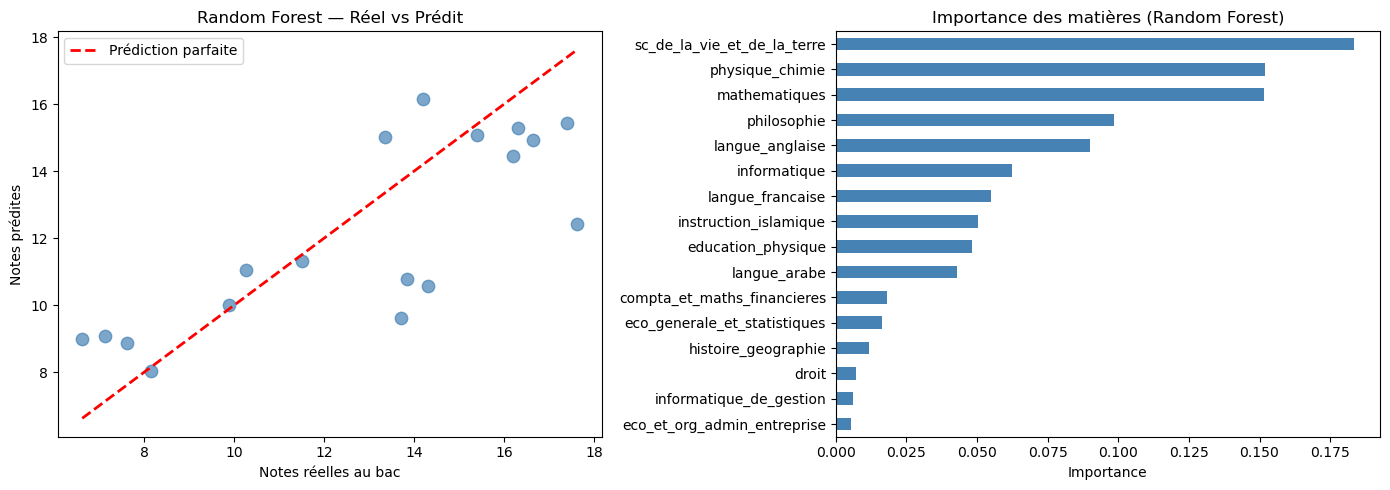

Graphiques sauvegardés dans output/


In [10]:
# ══════════════════════════════════════════════════
# SECTION 7 — VISUALISATION & ÉVALUATION
# ══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Graphique 1 : Valeurs réelles vs prédites ─────
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test)

axes[0].scatter(y_test, y_pred_rf, alpha=0.7, color='steelblue', s=80)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Notes réelles au bac')
axes[0].set_ylabel('Notes prédites')
axes[0].set_title('Random Forest — Réel vs Prédit')
axes[0].legend()

# ── Graphique 2 : Importance des features ─────────
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Importance des matières (Random Forest)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../output/evaluation_rf.png', dpi=150)
plt.show()

print("Graphiques sauvegardés dans output/")

In [11]:
# ══════════════════════════════════════════════════
# SECTION 8 — SAUVEGARDE DU MODÈLE FINAL
# ══════════════════════════════════════════════════
import joblib

# Sauvegarde du meilleur modèle
joblib.dump(rf_model, '../output/model_rf.joblib')

# Sauvegarde des noms de features
feature_names = list(X_train.columns)
joblib.dump(feature_names, '../output/feature_names.joblib')

print("Modèle sauvegardé :")
print("  output/model_rf.joblib")
print("  output/feature_names.joblib")
print()
print(f"Features utilisées ({len(feature_names)}) :")
for f in feature_names:
    print(f"  - {f}")
print()
print("✅ ML terminé — prêt pour Streamlit !")

Modèle sauvegardé :
  output/model_rf.joblib
  output/feature_names.joblib

Features utilisées (16) :
  - compta_et_maths_financieres
  - droit
  - eco_et_org_admin_entreprise
  - eco_generale_et_statistiques
  - education_physique
  - histoire_geographie
  - informatique
  - informatique_de_gestion
  - instruction_islamique
  - langue_anglaise
  - langue_arabe
  - langue_francaise
  - mathematiques
  - philosophie
  - physique_chimie
  - sc_de_la_vie_et_de_la_terre

✅ ML terminé — prêt pour Streamlit !
